In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io


In [2]:


# 1. Load Data
# csv_data = """sample_idx,method,mh_enabled,original_token,corrupted_token,predicted_token,success,l2_dist,kl_div
# 0,policy,True, Isles, prefix, files,False,0.8163520097732544,0.32988113164901733
# 0,policy,False, Isles, prefix,<|reserved_special_token_70|>,False,0.6598013043403625,3.133701801300049
# 0,grad_norm_preserved_random_dir,True, Isles, prefix, chapters,False,0.8716241717338562,0.8716026544570923
# 0,grad_norm_preserved_random_dir,False, Isles, prefix,"--)
# ",False,0.6813385486602783,5.494401931762695
# 0,random,True, Isles, prefix,Is,False,0.7780097723007202,5.744965076446533
# 0,random,False, Isles, prefix,	Y,False,0.8374089002609253,4.128081798553467
# 1,policy,True, to, RX, RX,False,0.7196217179298401,10.429235458374023
# 1,policy,False, to, RX, RX,False,0.7196217179298401,10.429235458374023
# 1,grad_norm_preserved_random_dir,True, to, RX, RX,False,0.7196217179298401,10.429235458374023
# 1,grad_norm_preserved_random_dir,False, to, RX, RX,False,0.7196217179298401,10.429235458374023
# 1,random,True, to, RX,еров,False,0.650724470615387,4.003364086151123
# 1,random,False, to, RX, Ayrıca,False,0.6783851981163025,8.37077808380127
# 2,policy,True, is,(yy,게,False,0.6075621843338013,1.4761654138565063
# 2,policy,False, is,(yy, tüket,False,0.35803288221359253,3.8878066539764404
# 2,grad_norm_preserved_random_dir,True, is,(yy,ーション,False,0.34839001297950745,3.5995097160339355
# 2,grad_norm_preserved_random_dir,False, is,(yy,,False,0.34820374846458435,1.4938247203826904
# 2,random,True, is,(yy, pokoj,False,0.6671500205993652,4.065908432006836
# 2,random,False, is,(yy, Deck,False,0.6515160799026489,5.177318572998047
# """

csv_path = "../GradientInformation/experiment_results_cls_single_oracle_True_samples_100_date_2026-03-11.csv"

df = pd.read_csv(csv_path)

# Clean up names for better plotting
df['Method Label'] = df['method'].replace({
    'policy': 'DLP Policy', 
    'grad_norm_preserved_random_dir': 'Grad Norm Noisy', 
    'random': 'Random Noise'
})

df['Sampling'] = df['mh_enabled'].replace({True: 'With MH', False: 'No MH'})


### Plotting Final Data for 70 samples

/tmp/ipykernel_3457852/2160944812.py:13: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df, x='Method Label', y='l2_dist', hue='Sampling', ax=axes[0],
/tmp/ipykernel_3457852/2160944812.py:25: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df, x='Method Label', y='kl_div', hue='Sampling', ax=axes[1],


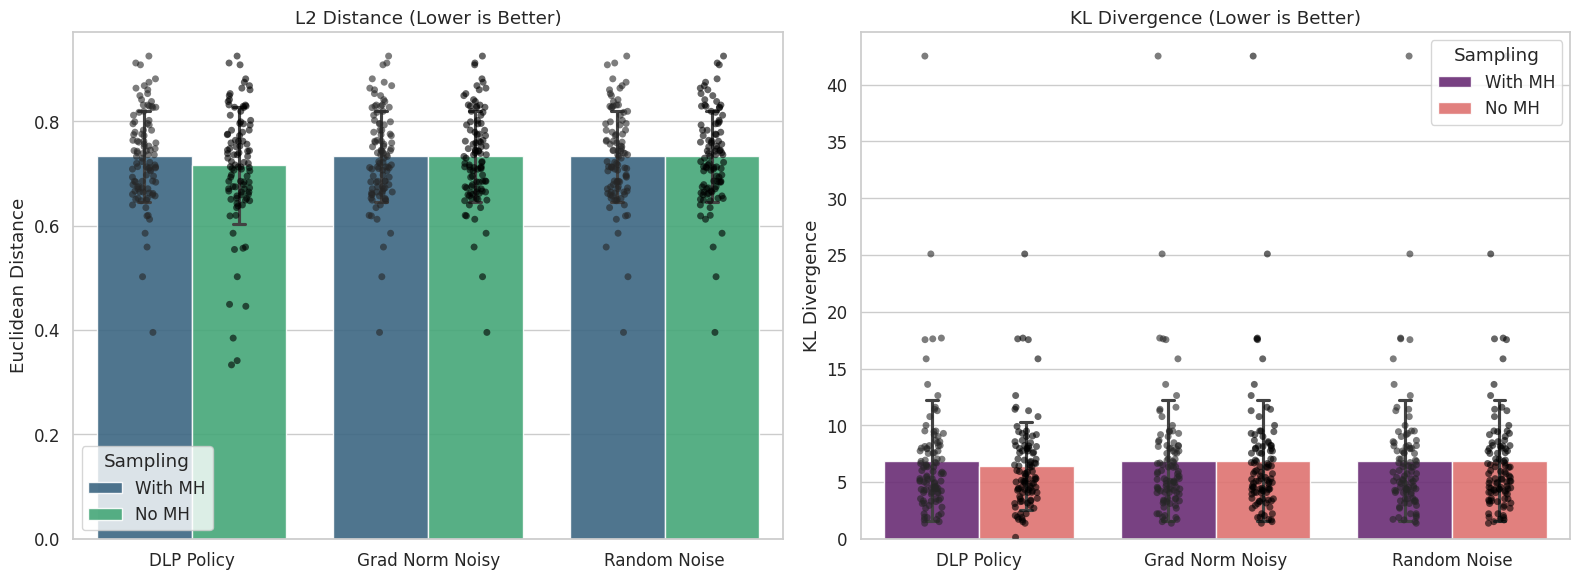

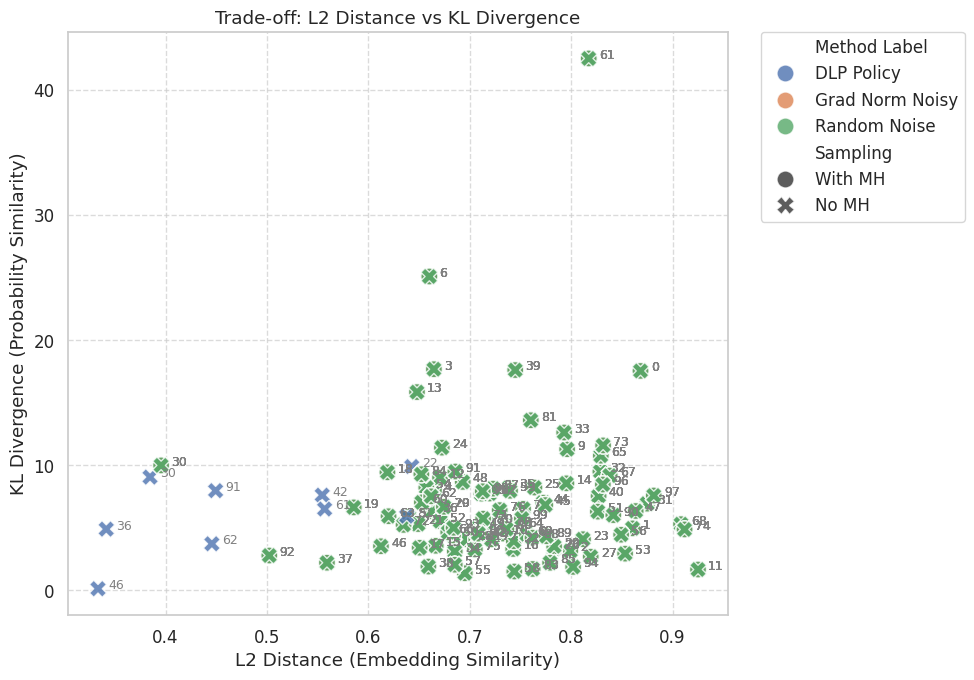

In [3]:

# Set Style
sns.set_theme(style="whitegrid", font_scale=1.1)

# =============================================================================
# PLOT 1: Grouped Bar Chart (The Summary)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot L2 Distance
sns.barplot(data=df, x='Method Label', y='l2_dist', hue='Sampling', ax=axes[0], 
            palette="viridis", errorbar='sd', capsize=.1, alpha=0.9)
# Add swarmplot to show individual data points (crucial for small N)
sns.stripplot(data=df, x='Method Label', y='l2_dist', hue='Sampling', ax=axes[0], 
              dodge=True, color='black', alpha=0.6, legend=False)

axes[0].set_title('L2 Distance (Lower is Better)')
axes[0].set_ylabel('Euclidean Distance')
axes[0].set_xlabel('')
axes[0].legend(title='Sampling')

# Plot KL Divergence
sns.barplot(data=df, x='Method Label', y='kl_div', hue='Sampling', ax=axes[1], 
            palette="magma", errorbar='sd', capsize=.1, alpha=0.9)
# Add swarmplot
sns.stripplot(data=df, x='Method Label', y='kl_div', hue='Sampling', ax=axes[1], 
              dodge=True, color='black', alpha=0.6, legend=False)

axes[1].set_title('KL Divergence (Lower is Better)')
axes[1].set_ylabel('KL Divergence')
axes[1].set_xlabel('')
axes[1].legend(title='Sampling')

plt.tight_layout()
plt.show()

# =============================================================================
# PLOT 2: Scatter Trade-off (The Deep Dive)
# =============================================================================
plt.figure(figsize=(10, 7))

# Create scatter plot
sns.scatterplot(
    data=df, 
    x='l2_dist', 
    y='kl_div', 
    hue='Method Label', 
    style='Sampling',
    s=150, # Marker size
    alpha=0.8,
    palette='deep'
)

# Add annotations for sample IDs so you can track specific failures
for i in range(df.shape[0]):
    plt.text(
        df.l2_dist[i]+0.01, 
        df.kl_div[i], 
        df.sample_idx[i], 
        fontsize=9, 
        color='gray'
    )

plt.title('Trade-off: L2 Distance vs KL Divergence')
plt.xlabel('L2 Distance (Embedding Similarity)')
plt.ylabel('KL Divergence (Probability Similarity)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.tight_layout()
plt.show()

### Plotting Traj Data

In [4]:
import ast

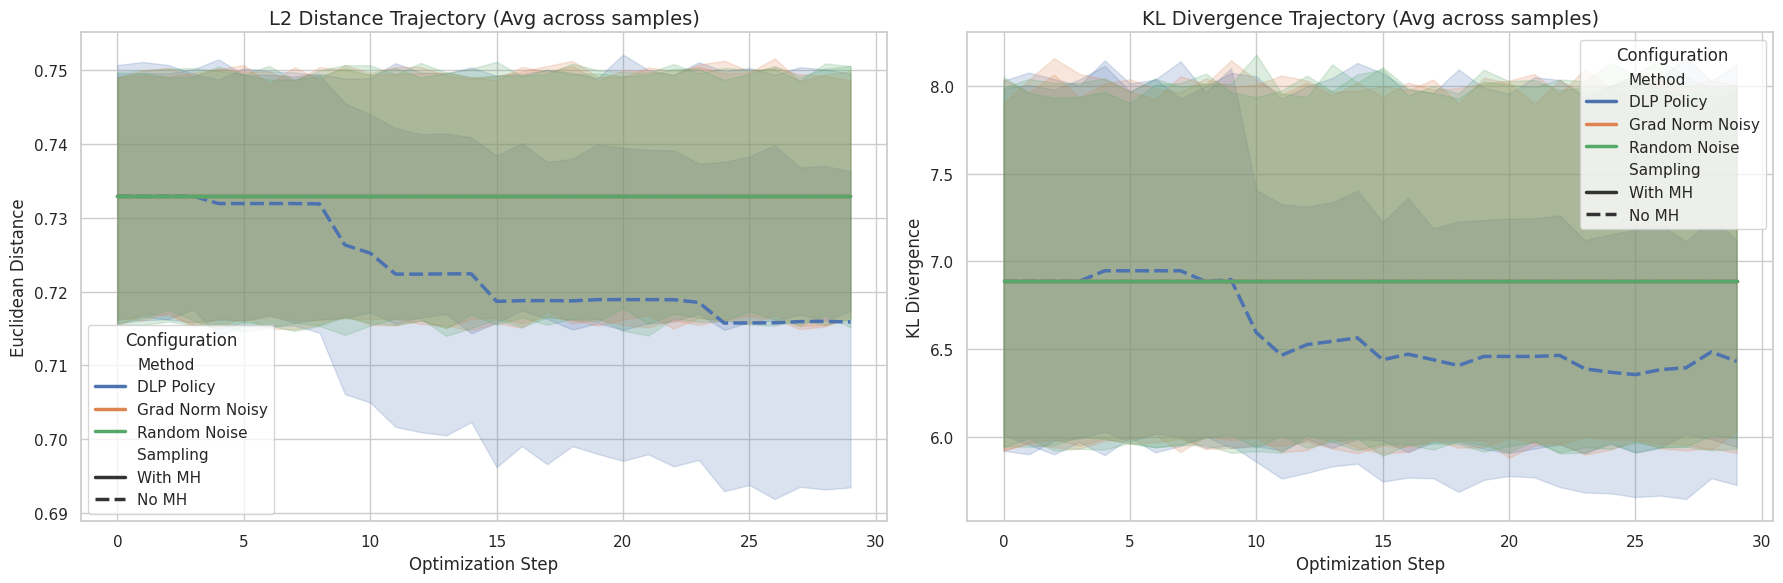

In [5]:
# # 1. Load Data
# Replace 'your_results_file.csv' with your actual filename
filename = '../GradientInformation/experiment_results_cls_single_oracle_True_samples_100_date_2026-03-11.csv' 
df_ = pd.read_csv(filename)

# 2. Preprocess: Parse the 'trajectory' string into actual Python lists
# The data comes in as a string representation of a list: "[{'step': 0...}, ...]"
# ast.literal_eval safely evaluates this string into a list of dictionaries
df_['trajectory'] = df_['trajectory'].apply(ast.literal_eval)

# 3. Flatten the data (Explode)
# We need to transform the data so that each row represents ONE step of ONE sample.
expanded_data = []

for _, row in df_.iterrows():
    method_name = row['method']
    mh_status = "With MH" if row['mh_enabled'] else "No MH"
    
    # Iterate through the trajectory list of this specific sample
    for step_log in row['trajectory']:
        expanded_data.append({
            "Method": method_name,
            "Sampling": mh_status,
            "Step": step_log['step'],
            "L2 Distance": step_log['l2_distance'],
            "KL Divergence": step_log['kl_divergence'],
            "Rejected": step_log.get('mh_rejected', False) # Optional: track rejections if needed
        })

# Create a clean DataFrame for plotting
plot_df = pd.DataFrame(expanded_data)

# Clean up Method names for better legend labels
plot_df['Method'] = plot_df['Method'].replace({
    'policy': 'DLP Policy',
    'grad_norm_preserved_random_dir': 'Grad Norm Noisy',
    'random': 'Random Noise'
})

# 4. Plotting
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: L2 Distance vs Step ---
sns.lineplot(
    data=plot_df,
    x="Step",
    y="L2 Distance",
    hue="Method",
    style="Sampling", # This makes 'With MH' solid and 'No MH' dashed (or dotted)
    markers=False,
    dashes=True,
    ax=axes[0],
    linewidth=2.5
)
axes[0].set_title("L2 Distance Trajectory (Avg across samples)", fontsize=14)
axes[0].set_ylabel("Euclidean Distance")
axes[0].set_xlabel("Optimization Step")
axes[0].legend(title="Configuration")

# --- Plot 2: KL Divergence vs Step ---
sns.lineplot(
    data=plot_df,
    x="Step",
    y="KL Divergence",
    hue="Method",
    style="Sampling",
    markers=False,
    dashes=True,
    ax=axes[1],
    linewidth=2.5
)
axes[1].set_title("KL Divergence Trajectory (Avg across samples)", fontsize=14)
axes[1].set_ylabel("KL Divergence")
axes[1].set_xlabel("Optimization Step")
# We usually don't need the legend on the second plot if it's identical, 
# but you can keep it or remove it:
axes[1].legend(title="Configuration")

plt.tight_layout()
plt.show()